In [42]:
import pandas as pd
import re
from collections import defaultdict, Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts



def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    raw_concepts= []
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        
        unit_concepts[unit].update(concepts)
        raw_concepts.extend(concepts)
        
    return unit_concepts, set(raw_concepts)
#how concepts removal same across algortihm


def find_cluster(raw_concept):
    for cluster in abs_map:
        if raw_concept in abs_map[cluster]:
            return cluster
def find_abstractions(expls):
    if isinstance(expls, set):
        glob = expls
    else:
        glob = set([i for j in expls.values() for i in j ])
    abstracts=[]
    exact_concepts_perabs=defaultdict(set)
    for concept in glob:
        raw_concept = concept.split(":")[-1]
        abstraction_cluster = find_cluster(raw_concept)
        if abstraction_cluster==143: 
            continue
        if not abstraction_cluster:abstraction_cluster=150
        exact_concepts_perabs[abstraction_cluster].add(raw_concept)
        
        abstracts.append(abstraction_cluster)
    return Counter(abstracts), set(abstracts), exact_concepts_perabs


In [43]:
def cluster_migration(dense_map, sparse_map):
    sn_sc=0
    sn_dc=0
    dn_sc=0
    dn_dc=0
    total = len(dense_map)
    common = dense_map.keys() & sparse_map.keys()
    for concept in common:
        d_cls = dense_map[concept]  # {cluster: [neurons]}
        s_cls = sparse_map[concept]

        d_pairs = {(cl, n) for cl, neurons in d_cls.items() for n in neurons}
        s_pairs = {(cl, n) for cl, neurons in s_cls.items() for n in neurons}

        # same neuron same cluster — (cl, n) exists in both
        if d_pairs & s_pairs:
            sn_sc += 1
            continue
        # same clus dif neron
        if d_cls.keys() & s_cls.keys(): # checks cluster number overlap ie [1,2,3] compare with [2,3] 
            #if at least 1 of the concept is expld at at least one of the same clusters and it didnt satisfy the snsc check it's a dn_sc
            dn_sc += 1
            continue
        
        #its not at the same cluster but collect all neurons that explain it across all clusters and see if theres an overlap (same cluster overlap wont be there so this collection will only account for different clusters anyway)
        dense_all_neurons_expld = set().union(*d_cls.values())
        sparse_all_neurons_expld = set().union(*s_cls.values())
        if dense_all_neurons_expld &sparse_all_neurons_expld:
            #diff clus same neuron
            sn_dc += 1
        else:
            #diff clus diff neuron
            dn_dc += 1
    return sn_sc/total, dn_sc/total, sn_dc/total, dn_dc/total

dense_map_test_1 = {'a': {1: [4,5,8], 2:[1,2,4]}, 'b': {1: [9], 3:[2,4]}, 'd':{1: [9],2:[6,8], 3:[2,4]}, 'e':{1: [9],2:[6,8], 3:[2,4]}} 
sparse_map_test_1 = {'a': {3:[7]}, 'b': {1: [9], 3:[12]}, 'c':{1: [9],2:[6,8], 3:[2,4]}}  
same_neuron_same_cluster, diff_neuron_same_cluster, same_neuron_diff_cluster, diff_neuron_diff_cluster = cluster_migration(dense_map_test_1, sparse_map_test_1)
assert same_neuron_same_cluster == 0.25 and diff_neuron_same_cluster == 0.0 and same_neuron_diff_cluster == 0.0 and diff_neuron_diff_cluster == 0.25


dense_map_test_2 = {'a': {1: [4,5,8], 2:[1,2,4]}, 'b': {1: [9], 3:[2,4]}, 'd':{1: [9],2:[6,8], 3:[2,4]}, 'e':{1: [9],2:[6,8], 3:[2,4]}} 
sparse_map_test_2 = {'a': {3:[4]}, 'b': {1: [9], 3:[12]}, 'c':{1: [9],2:[6,8], 3:[2,4]}}  
same_neuron_same_cluster, diff_neuron_same_cluster, same_neuron_diff_cluster, diff_neuron_diff_cluster = cluster_migration(dense_map_test_2, sparse_map_test_2)
assert same_neuron_same_cluster == 0.25 and diff_neuron_same_cluster == 0.0 and same_neuron_diff_cluster == 0.25 and diff_neuron_diff_cluster == 0.0


In [80]:
from collections import defaultdict
from collections import defaultdict
import numpy as np


def average_cluster_stability_with_error_bars(collective_list):
    values = defaultdict(lambda: defaultdict(list))

    for per_sparsity in collective_list.values():
        for sparsity, concept_dict in per_sparsity.items():
            for concept, stability in concept_dict.items():
                values[sparsity][concept].append(stability)

    results = {}

    for sparsity, concepts in values.items():
        results[sparsity] = {}

        for concept, observations in concepts.items():
            observations = np.asarray(observations, dtype=float)
            n = len(observations)

            mean = observations.mean()
            std = observations.std(ddof=1) if n > 1 else 0.0
            sem = std / np.sqrt(n) if n > 1 else 0.0

            results[sparsity][concept] = {
                "mean": mean,
                "std": std,
                "sem": sem,
                "n": n,
            }

    return results
test_collective= {
   0: {
       25.0: {
           'this': 0.0,
           'is': 1.0,
           'another': 0.5
       },
       43.0: {
           'there': 0.33,
           'are': 0.67,
           'multiple': 0.5
       }
       
   },
    1: {
       25.0: {
           'this': 0.5,
           'is': 1.0,
           'another': 0.33
       },
       43.0: {
           'there': 0.67,
           'are': 0.33,
           'multiple': 0.5
       }
       
   } 
}
    
average_cluster_stability_with_error_bars(test_collective)

{25.0: {'this': {'mean': 0.25, 'std': 0.3535533905932738, 'sem': 0.25, 'n': 2},
  'is': {'mean': 1.0, 'std': 0.0, 'sem': 0.0, 'n': 2},
  'another': {'mean': 0.41500000000000004,
   'std': 0.12020815280171307,
   'sem': 0.08499999999999999,
   'n': 2}},
 43.0: {'there': {'mean': 0.5,
   'std': 0.24041630560342617,
   'sem': 0.16999999999999998,
   'n': 2},
  'are': {'mean': 0.5,
   'std': 0.24041630560342617,
   'sem': 0.16999999999999998,
   'n': 2},
  'multiple': {'mean': 0.5, 'std': 0.0, 'sem': 0.0, 'n': 2}}}

In [44]:

def concept_map_at_cluster(mapping, c):
    concepts_and_neurons_at_clus = defaultdict(set)
    for cp in mapping:
        if c in mapping[cp]:
            for unit in mapping[cp][c]:
                concepts_and_neurons_at_clus[cp].add(unit)
    return concepts_and_neurons_at_clus
def neuron_migration(dense_map, sparse_map):
    stay =  defaultdict(float)
    moved=  defaultdict(float)
    lost= defaultdict(float)
    for cl in range(1,4):
        dense_map_at_cl = concept_map_at_cluster(dense_map, cl)
        sparse_map_at_cl = concept_map_at_cluster(sparse_map, cl)
        ttl=len(dense_map_at_cl)
        for cp in dense_map_at_cl:
            if cp not in sparse_map_at_cl:
                lost[cl] += 1
                continue
            if dense_map_at_cl[cp] & sparse_map_at_cl.get(cp,set()):
                stay[cl] += 1
            else:
                moved[cl] += 1
        lost[cl] /= ttl
        moved[cl] /= ttl
        stay[cl] /= ttl
    return stay, moved, lost

dense_map_test_1 = {'a': {1: [4,5,8], 2:[1,2,4]}, 'b': {1: [9], 3:[2,4]}, 'd':{1: [9],2:[6,8], 3:[2,4]}, 'e':{1: [9],2:[6,8], 3:[2,4]}} 
sparse_map_test_1 = {'a': {3:[7]}, 'b': {1: [9], 3:[12]}, 'c':{1: [9],2:[6,8], 3:[2,4]}} 
stay, moved, lost = neuron_migration(dense_map_test_1, sparse_map_test_1)
assert (stay[1]==0.25 and stay[2]==0.0 and stay[3]==0.0) and (moved[1]==0.0 and moved[2]==0.0 and moved[3]==1/3) and (lost[1]==0.75 and lost[2]==1.0 and lost[3]==2/3)

dense_map_test_2 = {'a': {1: [4,5,8], 2:[1,2,4]}, 'b': {1: [9], 3:[2,4]}, 'd':{1: [9],2:[6,8], 3:[2,4]}, 'e':{1: [9],2:[6,8], 3:[2,4]}} 
sparse_map_test_2 = {'a': {1:[4]}, 'b': {1: [9], 3:[12]}, 'c':{1: [9],2:[6,8], 3:[2,4]}}  
stay, moved, lost = neuron_migration(dense_map_test_2, sparse_map_test_2)
assert (stay[1]==0.5 and stay[2]==0.0 and stay[3]==0.0) and (moved[1]==0.0 and moved[2]==0.0 and moved[3]==1/3) and (lost[1]==0.5 and lost[2]==1.0 and lost[3]==2/3)

In [45]:
def concept_clus_mapp(clusters):
    back = defaultdict(set)
    for clus, raw in clusters.items():
        
        for unit, cps in raw.items():
            for cp in cps:
                back[cp].add(clus)
    return back
import json 
def load_mappings(path="/workspace/CCE_NLI/PaperExpOnly/PaperPlots/sparse_to_dense.json"):
    with open(path, 'r') as f:
        raw = json.load(f)
    mappings = {}
    for model, methods_dict in raw.items():
        mappings[model] = {}
        for method, runs_dict in methods_dict.items():
            mappings[model][method] = {}
            for run, iters_dict in runs_dict.items():
                mappings[model][method][run] = {}
                for iter_str, mapping in iters_dict.items():
                    mappings[model][method][run][int(iter_str)] = {
                        int(k): v for k, v in mapping.items()
                    }
    return mappings

def concept_cluster_neuron_map(clusters_to_unitmapping, mapp=None):
    back = defaultdict(lambda: defaultdict(set))
    for clus, unit_cp in clusters_to_unitmapping.items():
        for unit, cps in unit_cp.items():
            for cp in cps:
                if mapp is None:
                    back[cp][clus].add(unit)
                else:
                    back[cp][clus].add(mapp[unit])
    return back

def cluster_concept_neuron_map(clusters_to_unitmapping, mapp=None):
    back = defaultdict(lambda: defaultdict(set))
    for clus, unit_cp in clusters_to_unitmapping.items():
        for unit, cps in unit_cp.items():
            for cp in cps:
                if mapp is None:
                    back[clus][cp].add(unit)
                else:
                    back[clus][cp].add(mapp[unit])
    return back

In [46]:
pi_map = {0: 0.0, 1: 25.0, 2:43.75, 3:57.812, 4: 68.359, 5:76.27}

method_rename={'lottery_ticket': 'LOTTERY TICKET', 'wanda': 'WANDA', 'CoFi': 'CoFi'}
model_rename={'BERT':'BERT', 'BOWMAN': 'BiLSTM', 'LLAMA': 'LLAMA'}

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_cluster_stability(all_data):
    """
    all_data: {
        'BERT': {
            'CoFi':           {'snsc_avg': {1:..}, 'snsc_std': {1:..}, 'dnsc_avg':..., ...},
            'lottery_ticket': {...},
            'wanda':          {...},
        },
        'BOWMAN': {...},
        'LLAMA':  {...},
    }
    Rows = models, Cols = methods
    X    = sparsity level (outer key, e.g. 1-5)
    Stack= snsc / dnsc / sndc / dndc / lost
    """
    CATS = ['snsc', 'dnsc', 'sndc', 'dndc', 'lost']
    COLORS = {
        'snsc': '#2196F3',   # blue   – same neuron same cluster
        'dnsc': '#4CAF50',   # green  – diff neuron same cluster
        'sndc': '#FF9800',   # orange – same neuron diff cluster
        'dndc': '#9C27B0',   # purple – diff neuron diff cluster
        'lost': '#F44336',   # red    – lost
    }
    LABELS = {
        'snsc': 'Same N, Same C',
        'dnsc': 'Diff N, Same C',
        'sndc': 'Same N, Diff C',
        'dndc': 'Diff N, Diff C',
        'lost': 'Lost',
    }

    models  = list(all_data.keys())
    methods = list(dict.fromkeys(mt for m in all_data.values() for mt in m))  # preserve order
    n_rows, n_cols = len(models), len(methods)

    # infer layers from first available entry
    first_d = next(iter(next(iter(all_data.values())).values()))
    pis  = sorted(first_d['snsc_avg'].keys())
    x       = np.arange(len(pis))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 3.8 * n_rows),
        sharey=True, sharex=True,
        squeeze=False,
    )

    for r, model in enumerate(models):
        for c, method in enumerate(methods):
            ax = axes[r][c]

            if method not in all_data.get(model, {}):
                ax.set_visible(False)
                continue

            d      = all_data[model][method]
            bottom = np.zeros(len(pis))

            for cat in CATS:
                vals = np.array([d[f'{cat}_avg'][lk] for lk in pis])
                errs = np.array([d[f'{cat}_std'][lk] for lk in pis])

                ax.bar(
                    x, vals,
                    bottom=bottom,
                    color=COLORS[cat],
                    width=0.6,
                    label=LABELS[cat],
                    edgecolor='white',
                    linewidth=0.4,
                )
                top   = bottom + vals
                upper = np.maximum(np.minimum(top + errs, 1.0) - top, 0)
                lower = np.maximum(np.minimum(errs, top), 0)

                ax.errorbar(
                    x, top,
                    yerr=[lower, upper],
                    fmt='none',
                    ecolor='#222222',
                    elinewidth=0.9,
                    capsize=3,
                )
                
                for xi, (v, b) in enumerate(zip(vals, bottom)):
                    if v > 0.03:   # skip tiny segments — too cramped to label
                        ax.text(
                            xi, b + v / 2,
                            f'{v:.2f}',
                            ha='center', va='center',
                            fontsize=6.5,
                            fontweight='bold',
                            color='white',
                        )

                bottom += vals

            ax.set_ylim(0, 1.08)
            ax.set_xticks(x)
            ax.set_xticklabels([f'{pi_map[pi]}' for pi in pis], fontsize=8)
            ax.spines[['top', 'right']].set_visible(False)
            ax.grid(axis='y', linestyle='--', alpha=0.35, linewidth=0.6)

            # row / col headers
            if c == 0:
                ax.set_ylabel(model_rename[model], fontsize=11, fontweight='bold', labelpad=8)
            if r == 0:
                ax.set_title(method_rename[method], fontsize=11, fontweight='bold', pad=8)

    # shared legend at bottom
    handles = [mpatches.Patch(color=COLORS[c], label=LABELS[c]) for c in CATS]
    fig.legend(
        handles=handles,
        loc='lower center',
        ncol=len(CATS),
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
        fontsize=10,
    )

    fig.suptitle('Concept fate by model and pruning method', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'/workspace/CCE_NLI/PaperExpOnly/Refactored/cluster_stability.png', dpi=150, bbox_inches='tight')
    plt.show()
    
def plot_neuron_stability(all_data):
    """
    all_data: {
        'BERT':    {'CoFi': {...}, 'lottery_ticket': {...}, 'method3': {...}},
        'RoBERTa': {'CoFi': {...}, ...},
        'GPT':     {'CoFi': {...}, ...},
    }
    Rows    = models
    Columns = methods
    Within each subplot: x=layers, grouped bars per cluster, stacked stay/moved/lost
    """
    COLORS = {'stay': '#4CAF50', 'moved': '#FF9800', 'lost': '#F44336'}
    CATS   = ['stay', 'moved', 'lost']

    models  = list(all_data.keys())
    methods = list({mt for m in all_data.values() for mt in m.keys()})  # union of all methods
    n_rows  = len(models)
    n_cols  = len(methods)

    # infer layers + clusters from first available entry
    first_d    = next(iter(next(iter(all_data.values())).values()))
    pis     = sorted(first_d['stay_avg'].keys())
    clusters   = sorted(next(iter(first_d['stay_avg'].values())).keys())
    n_layers   = len(pis)
    n_clusters = len(clusters)

    bar_width  = 0.8 / n_clusters
    x_base     = np.arange(n_layers)
    cluster_colors_alpha = [0.55, 0.75, 0.95]   # one shade per cluster

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        sharey=True, sharex=True,
    )
    # normalise axes to always be 2-D
    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [axes]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]

    for r, model in enumerate(models):
        for c, method in enumerate(methods):
            ax = axes[r][c]

            if method not in all_data.get(model, {}):
                ax.set_visible(False)
                continue

            d = all_data[model][method]

            for ci, ck in enumerate(clusters):
                x      = x_base + ci * bar_width - (n_clusters - 1) * bar_width / 2
                bottom = np.zeros(n_layers)
                alpha  = cluster_colors_alpha[ci % len(cluster_colors_alpha)]

                for cat in CATS:
                    vals = np.array([d[f'{cat}_avg'][lk][ck] for lk in pis])
                    errs = np.array([d[f'{cat}_std'][lk][ck] for lk in pis])

                    ax.bar(
                        x, vals,
                        width=bar_width,
                        bottom=bottom,
                        color=COLORS[cat],
                        alpha=alpha,
                        edgecolor='white',
                        linewidth=0.4,
                    )
                    top   = bottom + vals
                    upper = np.maximum(np.minimum(top + errs, 1.0) - top, 0)
                    lower = np.maximum(np.minimum(errs, top), 0)

                    ax.errorbar(
                        x, top,
                        yerr=[lower, upper],
                        fmt='none',
                        ecolor='#222222',
                        elinewidth=0.8,
                        capsize=2,
                    )
                    for xi, (v, b) in enumerate(zip(vals, bottom)):
                        if v > 0.03:   # skip tiny segments — too cramped to label
                            ax.text(
                                x[xi], b + v / 2,
                                f'{v:.2f}',
                                ha='center', va='center',
                                fontsize=6.5,
                                fontweight='bold',
                                color='white',
                            )
                    bottom += vals
                    

            ax.set_ylim(0, 1.08)
            ax.set_xticks(x_base)
            ax.set_xticklabels([f'{pi_map[pi]}' for pi in pis], fontsize=8)
            ax.spines[['top', 'right']].set_visible(False)
            ax.grid(axis='y', linestyle='--', alpha=0.35)

            # row label (model) on left-most column only
            if c == 0:
                ax.set_ylabel(model_rename[model], fontsize=11, fontweight='bold')
            # col label (method) on top row only
            if r == 0:
                ax.set_title(method_rename[method], fontsize=11, fontweight='bold')

    # ── legend ──────────────────────────────────────────────────────────────
    cat_patches = [mpatches.Patch(color=COLORS[cat], label=cat.capitalize()) for cat in CATS]
    cluster_patches = [
        mpatches.Patch(facecolor='grey', alpha=cluster_colors_alpha[i], label=f'Cluster {ck}')
        for i, ck in enumerate(clusters)
    ]
    fig.legend(
        handles=cat_patches + cluster_patches,
        loc='lower center',
        ncol=len(cat_patches) + len(cluster_patches),
        bbox_to_anchor=(0.5, -0.03),
        frameon=False,
        fontsize=10,
    )

    fig.suptitle('Stay / Moved / Lost by model and pruning method', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('/workspace/CCE_NLI/PaperExpOnly/Refactored/neuron_stability.png', dpi=150, bbox_inches='tight')
    plt.show()


#neuron migration
def plot_feature_distribution_by_percent(data, bins=20, figsize=(18, 4),
                                          title="Feature Value Distribution"):
    percent_dict = {}
    for pct_key, list_of_lists in data.items():
        percent_dict[pct_key] = [d for sublist in list_of_lists for d in sublist]

    all_cluster_ids = set()
    for dict_list in percent_dict.values():
        for d in dict_list:
            for inner in d.values():
                all_cluster_ids.update(inner.keys())
    cluster_ids = sorted(all_cluster_ids)
    percents = sorted(percent_dict.keys())
    n_rows = len(percents)
    n_cols = len(cluster_ids)
    colors = ["steelblue", "mediumseagreen", "tomato", "mediumpurple", "orange"]

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize[0], figsize[1] * n_rows),
                             sharey=False, squeeze=False)

    print(f"{'Sparsity':<12} {'Cluster':>9} {'Mean':>8} {'Var':>10}")
    print("-" * 45)

    for row_idx, pct in enumerate(percents):
        dict_list = percent_dict[pct]

        cluster_values = defaultdict(list)
        for d in dict_list:
            per_dict = defaultdict(list)
            for key, inner in d.items():
                for cluster_id, val in inner.items():
                    per_dict[cluster_id].append(val)
            for cluster_id, vals in per_dict.items():
                cluster_values[cluster_id].append(np.array(vals))

        for col_idx, (cluster_id, color) in enumerate(zip(cluster_ids, colors)):
            ax = axes[row_idx][col_idx]

            if cluster_id not in cluster_values or not cluster_values[cluster_id]:
                ax.set_visible(False)
                continue

            val_list = cluster_values[cluster_id]
            all_vals = np.concatenate(val_list)
            mean, var = all_vals.mean(), all_vals.var()

            print(f"{str(pi_map[pct]):<12} {cluster_id:>9} {mean:>8.4f} {var:>10.6f}")

            _, edges = np.histogram(all_vals, bins=bins)
            bin_counts = np.array([
                np.histogram(vals, bins=edges)[0] for vals in val_list
            ], dtype=float)

            avg_counts = bin_counts.mean(axis=0)
            std_counts = bin_counts.std(axis=0)
            bin_centers = (edges[:-1] + edges[1:]) / 2
            bin_width   = edges[1] - edges[0]

            ax.bar(bin_centers, avg_counts, width=bin_width * 0.85,
                   color=color, alpha=0.8, edgecolor="white", linewidth=0.5,
                   label="Avg count")
            ax.errorbar(bin_centers, avg_counts, yerr=std_counts,
                        fmt="none", color="black", capsize=3, linewidth=1.2,
                        label="±1 Std")

            # Annotate mean & var directly on the plot
            ax.text(0.97, 0.95, f"μ={mean:.3f}\nσ²={var:.4f}",
                    transform=ax.transAxes, fontsize=8, va="top", ha="right",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

            if col_idx == 0:
                ax.set_ylabel(f"Sparsity: {pi_map[pct]}\nAvg Count", fontsize=11)
            if row_idx == 0:
                ax.set_title(f"Cluster {cluster_id}", fontsize=12)
            ax.set_xlabel("% of Occurences at the Same Neuron", fontsize=9)
            ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
#cluster migration plotting
import numpy as np
import matplotlib.pyplot as plt

def get_sparsity_levels(collective_list):
    # extract and sort sparsity keys by numeric value
    keys = list(collective_list[0][0].keys())
    return sorted(keys, key=lambda s: float(s.replace('%Pruned', '')))

def plot_cluster_migration_per_sparsity(collective_list, sparsity=None, bins=20, filter_prefix=None):

    all_values = [
        val
        for feat, val in collective_list[0][sparsity].items()
        if filter_prefix is None or feat.startswith(filter_prefix)
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(all_values, bins=bins, range=(0, 1), color="#378ADD", edgecolor="#185FA5", alpha=0.85)
    ax.set_xlabel("feature value")
    ax.set_ylabel("# concepts")
    ax.set_title(f"Feature value distribution — {sparsity}, {len(collective_list)} runs"
                 + (f"  [{filter_prefix}*]" if filter_prefix else ""))
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_value_histogram_by_sparsity(collective_list, bins=20, filter_prefix=None):
    sparsity_levels = get_sparsity_levels(collective_list)
    n = len(sparsity_levels)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=True, sharex=True)
    if n == 1:
        axes = [axes]

    for ax, s in zip(axes, sparsity_levels):
        vals = [
            val
            for run in collective_list
            for feat, val in run[0][s].items()
            if filter_prefix is None or feat.startswith(filter_prefix)
        ]
        ax.hist(vals, bins=bins, range=(0, 1), color="#378ADD", edgecolor="#185FA5", alpha=0.85)
        ax.set_title(s)
        ax.set_xlabel("feature value")
        ax.spines[["top", "right"]].set_visible(False)

    axes[0].set_ylabel("# concepts")
    fig.suptitle("Feature value distributions across sparsity levels"
                 + (f"  [{filter_prefix}*]" if filter_prefix else ""), y=1.02)
    plt.tight_layout()
    plt.show()


Neuron Stability Concept Distribution

In [95]:
def percent_where_stable(dense_encs, sparse_encs):
    return len(dense_encs & sparse_encs)/len(dense_encs) #what percent of old neurons still c
def get_avgs_and_err(avg_list):
    avgs=defaultdict(lambda: defaultdict(float))
    stds=defaultdict(lambda: defaultdict(float))
    for index in avg_list:
        for cluster in avg_list[index]:
            avgs[index][cluster] = np.array(avg_list[index][cluster]).mean()
            stds[index][cluster]  = np.array(avg_list[index][cluster]).std()
    return avgs, stds
        
#mapp = load_mappings()
RUNS= {'lottery_ticket': [1,2,3], 'wanda': [1,2,3], 'CoFi': [f'5_redone',6,7]}
pi_map = {0: 0.0, 1: 25.0, 2:43.75, 3:57.812, 4: 68.359, 5:76.27}

method_rename={'lottery_ticket': 'LOTTERY TICKET', 'wanda': 'WANDA', 'CoFi': 'CoFi'}
model_rename={'BERT':'BERT', 'BOWMAN': 'BiLSTM', 'LLAMA': 'LLAMA'}

compiled_model_method_neuron_stability = defaultdict(lambda: defaultdict(lambda: defaultdict))
for model in ['LLAMA']:
    for method in ['wanda']:
        dense_cluster_unit_concpt_map={}
        sparse_cluster_unit_concpt_map={}
        stay_avg = defaultdict(lambda: defaultdict(list))
        moved_avg = defaultdict(lambda: defaultdict(list))
        
        lost_avg = defaultdict(lambda: defaultdict(list))
        collective_list = defaultdict(list)
        
        
            
        
        for run in RUNS[method]:
            per_sparsity_dict_list = []
            path = f'/workspace/CCE_NLI/{model}/exp/{method}/Run{run}/Expls'
            idx = 0
            for sparsity in sorted(os.listdir(path)):
   
                if '.ipynb' in sparsity or '.csv' in sparsity: continue
                

                for cluster in range(1,4):
                    if  f'Cluster{cluster}IOUS1024N.csv' not in os.listdir(os.path.join(path, sparsity)):
                        continue

                    if sparsity == '0.0%Pruned':
                        unit_concept_map, indiv_concepts = load_csv_data(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                        #print(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                        dense_cluster_unit_concpt_map[cluster] = unit_concept_map
                    if sparsity != '0.0%Pruned':
                        unit_concept_map, indiv_concepts = load_csv_data(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                        sparse_cluster_unit_concpt_map[cluster] = unit_concept_map

                dense_concept2cluster2neuron = concept_cluster_neuron_map(dense_cluster_unit_concpt_map)

                if sparsity=='0.0%Pruned': 
                    idx += 1
                    continue

                stability_dist = defaultdict(lambda: defaultdict(float))
                if method=='CoFi':
                    sparse_concept2cluster2neuron = concept_cluster_neuron_map(sparse_cluster_unit_concpt_map,  reammpa_llama) #mapp[model]['CoFi'][f'Run0.25_{run}'][idx])
                else:
                    sparse_concept2cluster2neuron = concept_cluster_neuron_map(sparse_cluster_unit_concpt_map)

                common = set(list(sparse_concept2cluster2neuron.keys())) & set(list(dense_concept2cluster2neuron.keys()))
                for concept in common:
                    for cluster in range(1,4):
                        if dense_concept2cluster2neuron[concept].get(cluster,set()) and sparse_concept2cluster2neuron[concept].get(cluster,set()):
                            # iou to measure overlap of neurons that activated in the sparse and dense at this cluster for this concept
                            stability_dist[concept][cluster] = percent_where_stable(dense_concept2cluster2neuron[concept][cluster], sparse_concept2cluster2neuron[concept][cluster]) #mig for this sparsity
                per_sparsity_dict_list.append(stability_dist)

                if sparsity!='0.0%Pruned':
                    #print(idx, sparsity)
                    
                    collective_list[idx].append(per_sparsity_dict_list) 
                idx += 1


CLUSTER MIGRATION

In [81]:
def percent_where_stable(dense_encs, sparse_encs):
    return len(dense_encs.keys() & sparse_encs.keys())/len(dense_encs.keys() | sparse_encs.keys())
def get_avgs_and_err(avg_list):
    avgs=defaultdict(lambda: defaultdict(float))
    stds=defaultdict(lambda: defaultdict(float))
    for index in avg_list:
        for cluster in avg_list[index]:
            avgs[index][cluster] = np.array(avg_list[index][cluster]).mean()
            stds[index][cluster]  = np.array(avg_list[index][cluster]).std()
    return avgs, stds
        
#mapp = load_mappings()
RUNS= {'lottery_ticket': [1,2,3], 'wanda': [1,2,3], 'CoFi': [f'5_redone',6,7]}
pi_map = {0: 0.0, 1: 25.0, 2:43.75, 3:57.812, 4: 68.359, 5:76.27}

method_rename={'lottery_ticket': 'LOTTERY TICKET', 'wanda': 'WANDA', 'CoFi': 'CoFi'}
model_rename={'BERT':'BERT', 'BOWMAN': 'BiLSTM', 'LLAMA': 'LLAMA'}

compiled_model_method_neuron_stability = defaultdict(lambda: defaultdict(lambda: defaultdict))
for model in ['LLAMA']:
    for method in ['lottery_ticket']:
        dense_cluster_unit_concpt_map={}
        sparse_cluster_unit_concpt_map={}
        stay_avg = defaultdict(lambda: defaultdict(list))
        moved_avg = defaultdict(lambda: defaultdict(list))
        
        lost_avg = defaultdict(lambda: defaultdict(list))
        collective_list = defaultdict(list)
        idx = 0
            
        for run in RUNS[method]:
            path = f'/workspace/CCE_NLI/{model}/exp/{method}/Run{run}/Expls'
            per_sparsity_dict_list = defaultdict(list)
            for sparsity in sorted(os.listdir(path)):
                
                if '.ipynb' in sparsity or '.csv' in sparsity: continue
            
                for cluster in range(1,4):
                    if  f'Cluster{cluster}IOUS1024N.csv' not in os.listdir(os.path.join(path, sparsity)):
        
                        continue
                    
                    if sparsity == '0.0%Pruned':
                        unit_concept_map, indiv_concepts = load_csv_data(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                        #print(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                        dense_cluster_unit_concpt_map[cluster] = unit_concept_map
                    if sparsity != '0.0%Pruned':
                        unit_concept_map, indiv_concepts = load_csv_data(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                        sparse_cluster_unit_concpt_map[cluster] = unit_concept_map
                
                dense_concept2cluster2neuron = concept_cluster_neuron_map(dense_cluster_unit_concpt_map)
                
                if sparsity=='0.0%Pruned': continue
 
                stability_dist = defaultdict(lambda: defaultdict(float))
                if method=='CoFi':
                    sparse_concept2cluster2neuron = concept_cluster_neuron_map(sparse_cluster_unit_concpt_map,  reammpa_llama) #mapp[model]['CoFi'][f'Run0.25_{run}'][idx])
                else:
                    sparse_concept2cluster2neuron = concept_cluster_neuron_map(sparse_cluster_unit_concpt_map)
                
                common = set(list(sparse_concept2cluster2neuron.keys())) & set(list(dense_concept2cluster2neuron.keys()))
                for concept in common:
                    if dense_concept2cluster2neuron[concept].get(cluster,set()) and sparse_concept2cluster2neuron[concept].get(cluster,set()):
                        
                 
                        stability_dist[concept] = percent_where_stable(dense_concept2cluster2neuron[concept], sparse_concept2cluster2neuron[concept]) #mig for this sparsity
                per_sparsity_dict_list[sparsity]=stability_dist
          
                if sparsity!='0.0%Pruned':
                    collective_list[idx] = per_sparsity_dict_list
            idx += 1
averaged = average_cluster_stability_with_error_bars(collective_list)

CLUSTER MIGRATION -- printing the stats

defaultdict(<class 'list'>, {25.0: [array([0.33333333, 0.        , 0.        , 0.        , 0.        ,
       0.33333333, 0.        , 0.        , 0.        , 0.33333333]), array([0.        , 0.        , 0.        , 0.33333333, 0.        ,
       0.33333333, 0.        , 0.        , 0.        , 0.33333333])], 43.0: [array([0.        , 0.        , 0.        , 0.33333333, 0.        ,
       0.33333333, 0.33333333, 0.        , 0.        , 0.        ]), array([0.        , 0.        , 0.        , 0.33333333, 0.        ,
       0.33333333, 0.33333333, 0.        , 0.        , 0.        ])]})
Sparsity 25.0
Mean fractions: [0.16666667 0.         0.         0.16666667 0.         0.33333333
 0.         0.         0.         0.33333333]
SEM: [0.16666667 0.         0.         0.16666667 0.         0.
 0.         0.         0.         0.        ]


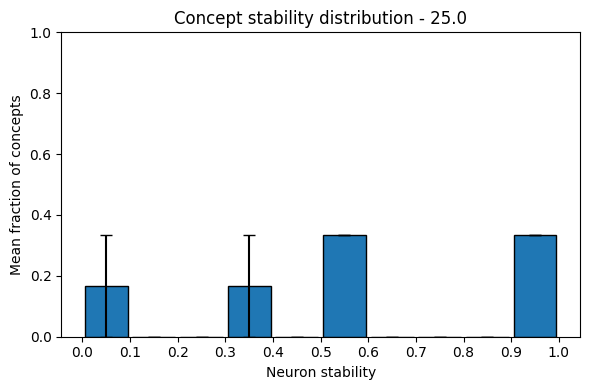

Sparsity 43.0
Mean fractions: [0.         0.         0.         0.33333333 0.         0.33333333
 0.33333333 0.         0.         0.        ]
SEM: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


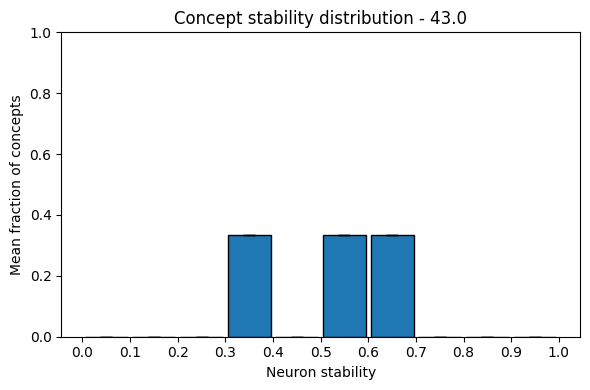

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


def plot_histograms_with_error_bars(collective_list):
    bins = np.linspace(0, 1, 11)
    histograms = defaultdict(list)

    # collective_list: {run: {sparsity: {concept: stability}}}
    for run_data in collective_list.values():
        for sparsity, concept_stability in run_data.items():
            values = np.asarray(
                list(concept_stability.values()),
                dtype=float,
            )

            counts, edges = np.histogram(values, bins=bins)

            # Normalize independently for each run
            fractions = counts / len(values)
            histograms[sparsity].append(fractions)
    

    centers = (bins[:-1] + bins[1:]) / 2
    print(histograms)

    for sparsity, run_histograms in histograms.items():
        run_histograms = np.asarray(run_histograms)

        mean_counts = run_histograms.mean(axis=0)

        if len(run_histograms) > 1:
            sem_counts = (
                run_histograms.std(axis=0, ddof=1)
                / np.sqrt(len(run_histograms))
            )
        else:
            sem_counts = np.zeros_like(mean_counts)

        plt.figure(figsize=(6, 4))

        plt.bar(
            centers,
            mean_counts,
            yerr=sem_counts,
            width=0.09,
            capsize=4,
            edgecolor="black",
        )

        print(f"Sparsity {sparsity}")
        print("Mean fractions:", mean_counts)
        print("SEM:", sem_counts)

        plt.xlabel("Neuron stability")
        plt.ylabel("Mean fraction of concepts")
        plt.title(f"Concept stability distribution - {sparsity}")
        plt.xticks(np.arange(0, 1.1, 0.1))
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()

'''
{25.0: {'this': {'mean': 0.25, 'std': 0.3535533905932738, 'sem': 0.25, 'n': 2},
  'is': {'mean': 1.0, 'std': 0.0, 'sem': 0.0, 'n': 2},
  'another': {'mean': 0.41500000000000004,
   'std': 0.12020815280171307,
   'sem': 0.08499999999999999,
   'n': 2}},
 43.0: {'there': {'mean': 0.5,
   'std': 0.24041630560342617,
   'sem': 0.16999999999999998,
   'n': 2},
  'are': {'mean': 0.5,
   'std': 0.24041630560342617,
   'sem': 0.16999999999999998,
   'n': 2},
  'multiple': {'mean': 0.5, 'std': 0.0, 'sem': 0.0, 'n': 2}}}
'''
plot_histograms_with_error_bars(test_collective)

CLUSTER MIGRATION - plotting the stats

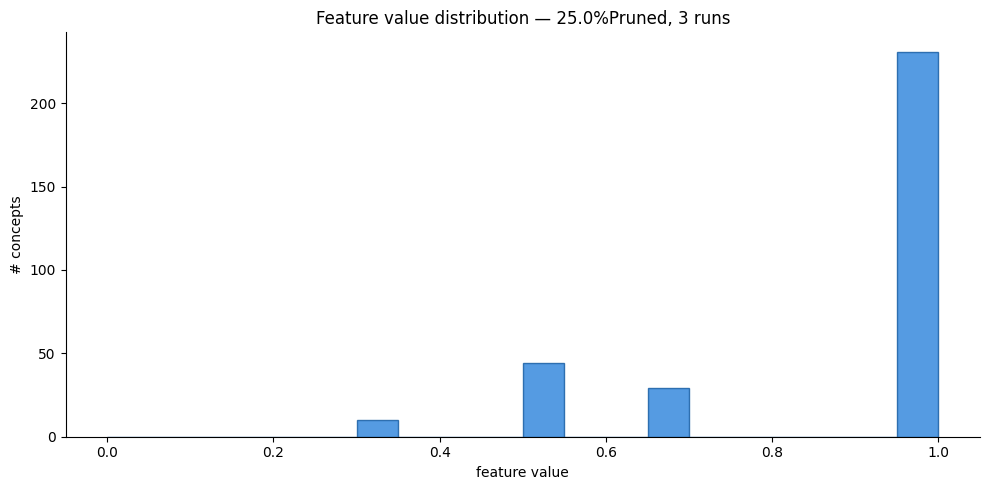

In [164]:
plot_cluster_migration_per_sparsity(collective_list, sparsity='25.0%Pruned')

Sparsity       Cluster     Mean        Var
---------------------------------------------
0.0                  1   0.1721   0.042158
0.0                  2   0.3432   0.074369
0.0                  3   0.4373   0.098517
25.0                 1   0.1756   0.044580
25.0                 2   0.3468   0.075545
25.0                 3   0.4390   0.098723
43.75                1   0.1756   0.044580
43.75                2   0.3468   0.075545
43.75                3   0.4390   0.098723
57.812               1   0.1756   0.044580
57.812               2   0.3468   0.075545
57.812               3   0.4390   0.098723
68.359               1   0.1756   0.044580
68.359               2   0.3468   0.075545
68.359               3   0.4390   0.098723
76.27                1   0.1825   0.049323
76.27                2   0.3539   0.077772
76.27                3   0.4423   0.099120


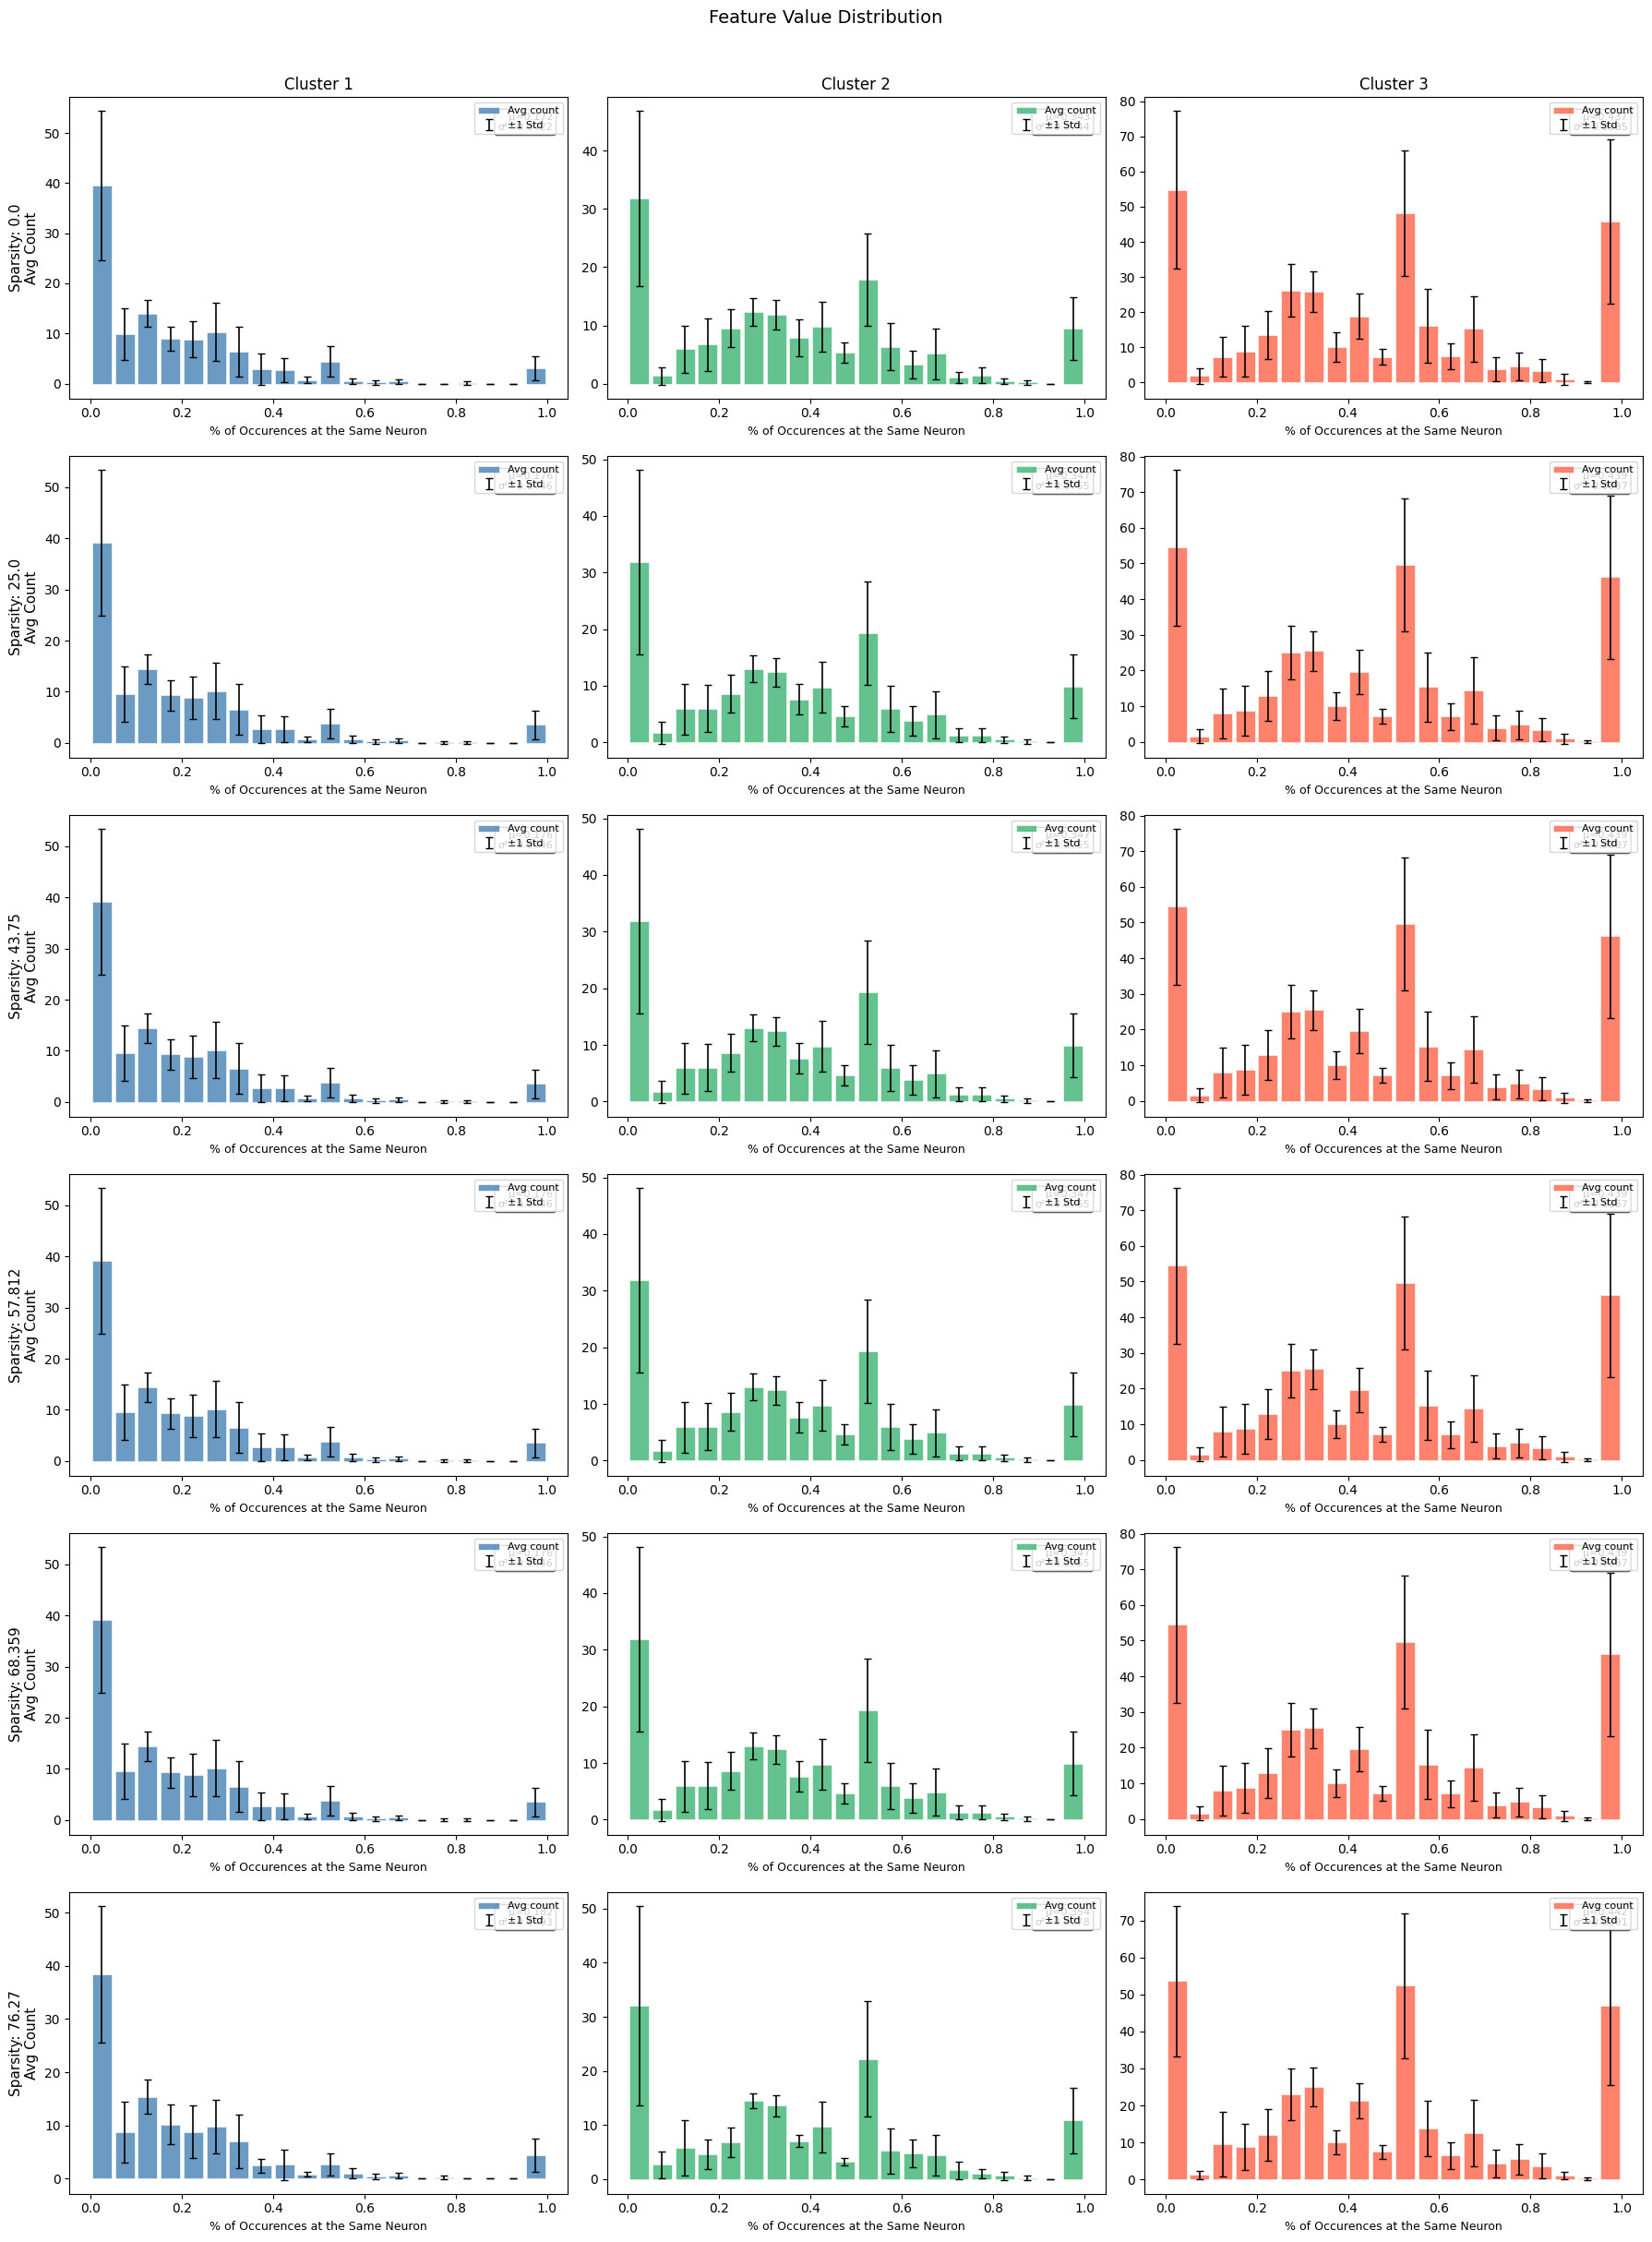

In [26]:
plot_feature_distribution_by_percent(collective_list)

NEURON STABILITY

NEURON STABILITY: STAY WITH SAME NEURON | MODEL: LLAMA | METHOD: wanda
	Sparsity: 25.0
		Cluster: 1 | Neuron Stability: [0.6713286713286714, 0.6083916083916084, 0.6573426573426573]
		Cluster: 2 | Neuron Stability: [0.7671957671957672, 0.6878306878306878, 0.7248677248677249]
		Cluster: 3 | Neuron Stability: [0.735224586288416, 0.7092198581560284, 0.7328605200945626]
	Sparsity: 43.75
		Cluster: 1 | Neuron Stability: [0.6573426573426573, 0.6503496503496503, 0.6223776223776224]
		Cluster: 2 | Neuron Stability: [0.7195767195767195, 0.6878306878306878, 0.6825396825396826]
		Cluster: 3 | Neuron Stability: [0.7281323877068558, 0.7115839243498818, 0.7659574468085106]
	Sparsity: 57.812
		Cluster: 1 | Neuron Stability: [0.5594405594405595, 0.5244755244755245, 0.5664335664335665]
		Cluster: 2 | Neuron Stability: [0.6243386243386243, 0.6243386243386243, 0.6190476190476191]
		Cluster: 3 | Neuron Stability: [0.6501182033096927, 0.6453900709219859, 0.640661938534279]
	Sparsity: 68.359
		Cluster: 1 | N

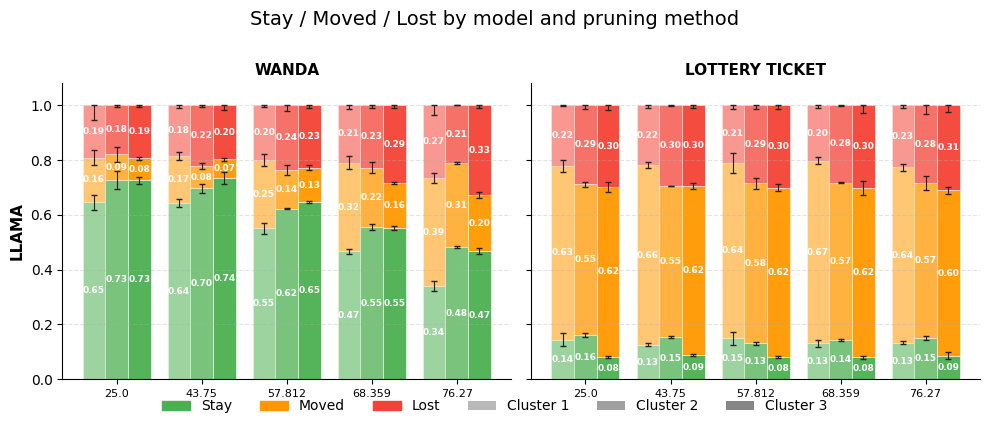

In [50]:
def get_avgs_and_err(avg_list):
    avgs=defaultdict(lambda: defaultdict(float))
    stds=defaultdict(lambda: defaultdict(float))
    for index in avg_list:
        for cluster in avg_list[index]:
            avgs[index][cluster] = np.array(avg_list[index][cluster]).mean()
            stds[index][cluster]  = np.array(avg_list[index][cluster]).std()
    return avgs, stds
        
#mapp = load_mappings()
RUNS= {'lottery_ticket': [1,2,3], 'wanda': [1,2,3], 'CoFi': [f'5_redone',6,7]}
pi_map = {0: 0.0, 1: 25.0, 2:43.75, 3:57.812, 4: 68.359, 5:76.27}

method_rename={'lottery_ticket': 'LOTTERY TICKET', 'wanda': 'WANDA', 'CoFi': 'CoFi'}
model_rename={'BERT':'BERT', 'BOWMAN': 'BiLSTM', 'LLAMA': 'LLAMA'}

compiled_model_method_neuron_stability = defaultdict(lambda: defaultdict(lambda: defaultdict))
for model in ['LLAMA']:
    for method in ['wanda', 'lottery_ticket']:
        dense_cluster_unit_concpt_map={}
        sparse_cluster_unit_concpt_map={}
        stay_avg = defaultdict(lambda: defaultdict(list))
        moved_avg = defaultdict(lambda: defaultdict(list))
        
        lost_avg = defaultdict(lambda: defaultdict(list))
        
        
        for run in RUNS[method]:
            path = f'/workspace/CCE_NLI/{model}/exp/{method}/Run{run}/Expls'
            
            idx=1
            
            for sparsity in sorted(os.listdir(path)):
                if '.ipynb' in sparsity: continue
                
                for cluster in range(1,4):
                    if  f'Cluster{cluster}IOUS1024N.csv' not in os.listdir(os.path.join(path, sparsity)):
                        continue
                    
                    if sparsity == '0.0%Pruned':
                        unit_concept_map, indiv_concepts = load_csv_data(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                        #print(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                        dense_cluster_unit_concpt_map[cluster] = unit_concept_map
                    if sparsity != '0.0%Pruned':
                        unit_concept_map, indiv_concepts = load_csv_data(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                        sparse_cluster_unit_concpt_map[cluster] = unit_concept_map
                    
                dense_concept2cluster2neuron = concept_cluster_neuron_map(dense_cluster_unit_concpt_map)
                if sparsity=='0.0%Pruned': continue
 
                if method=='CoFi':
                    sparse_concept2cluster2neuron = concept_cluster_neuron_map(sparse_cluster_unit_concpt_map,  reammpa_llama) #mapp[model]['CoFi'][f'Run0.25_{run}'][idx])
                else:
                    sparse_concept2cluster2neuron = concept_cluster_neuron_map(sparse_cluster_unit_concpt_map)
               
                stay, moved, lost = neuron_migration(dense_concept2cluster2neuron, sparse_concept2cluster2neuron) #mig for this sparsity
       
                for c in range(1,4):
                    stay_avg[idx][c].append(stay[c])
                    moved_avg[idx][c].append(moved[c])
                    lost_avg[idx][c].append(lost[c])
               
                idx += 1
        #print(model, method, "\n STAYED", stay_avg)# "\n\nmoved", moved_avg, "\n rror move ", moved_std, "\n\nlost", lost_avg)
        print(f"NEURON STABILITY: STAY WITH SAME NEURON | MODEL: {model} | METHOD: {method}")
        for i in stay_avg:
            print(f"\tSparsity: {pi_map[i]}")
            for cluster in stay_avg[i]:
                print(f"\t\tCluster: {cluster} | Neuron Stability: {stay_avg[i][cluster]}")
        print(f"NEURON STABILITY: MOVED TO DIFF NEURON | MODEL: {model} | METHOD: {method}")
        for i in moved_avg:
            print(f"\tSparsity: {pi_map[i]}")
            for cluster in moved_avg[i]:
                print(f"\t\tCluster: {cluster} | Neuron Stability: {moved_avg[i][cluster]}")
        print(f"NEURON STABILITY: LOST AT CLUSTER| MODEL: {model} | METHOD: {method}")
        for i in lost_avg:
            print(f"\tSparsity: {pi_map[i]}")
            for cluster in lost_avg[i]:
                print(f"\t\tCluster: {cluster} | Neuron Stability: {lost_avg[i][cluster]}")
                
        stay_avg, stay_std = get_avgs_and_err(stay_avg)
        moved_avg, moved_std = get_avgs_and_err(moved_avg)
        lost_avg, lost_std = get_avgs_and_err(lost_avg)
        compiled_model_method_neuron_stability[model][method] = {'stay_avg': stay_avg, 'stay_std': stay_std, 'moved_avg':moved_avg, 'moved_std': moved_std, 'lost_avg': lost_avg, 'lost_std': lost_std}
        #print(model, method, "\n\nstay", stay_avg, "\nerror stay ", stay_std, "\n\nmoved", moved_avg, "\n rror move ", moved_std, "\n\nlost", lost_avg)
        
        #plot_neuron_stability(stay_avg, stay_std, moved_avg, moved_std, lost_avg, lost_std)
        #return stay_avg, moved_avg, lost_avg
           
plot_neuron_stability(compiled_model_method_neuron_stability)   


CLUSTER STABILITY

In [47]:
def get_avgs_and_err(avg_list):
    avgs=defaultdict()
    stds=defaultdict()
    for index in avg_list:
        for cluster in avg_list[index]:
            avgs[index] = np.array(avg_list[index]).mean()
            stds[index] = np.array(avg_list[index]).std()
    return avgs, stds
        
#mapp = load_mappings()
compiled_model_method_cluster_stability = defaultdict(lambda: defaultdict(lambda: defaultdict (lambda: defaultdict)))
RUNS= {'lottery_ticket': [1,2,3], 'wanda': [1,2,3], 'CoFi': ['5_StartingFromLTH']}
for model in ['LLAMA']:
    for method in ['wanda', 'lottery_ticket']:
        dense_cluster_unit_concpt_map={}
        sparse_cluster_unit_concpt_map={}
        snsc_avg = defaultdict(list)
        dnsc_avg = defaultdict(list)
        sndc_avg = defaultdict(list)
        dndc_avg = defaultdict(list)
        lost = defaultdict(list)
        
        
        for run in RUNS[method]:
            path = f'/workspace/CCE_NLI/{model}/exp/{method}/Run{run}/Expls'
            
            if '0.0%Pruned' in os.listdir(path):
                idx = 0
            else:
                idx=1
            for sparsity in sorted(os.listdir(path)):
                if '.ipynb' in sparsity: continue
                
                for cluster in range(1,4):
                    if  f'Cluster{cluster}IOUS1024N.csv' not in os.listdir(os.path.join(path, sparsity)):
                        continue
                    unit_concept_map, indiv_concepts = load_csv_data(os.path.join(path, sparsity, f'Cluster{cluster}IOUS1024N.csv'))
                    if sparsity == '0.0%Pruned':
                        dense_cluster_unit_concpt_map[cluster] = unit_concept_map
                    else:
                        sparse_cluster_unit_concpt_map[cluster] = unit_concept_map
                if sparsity == '0.0%Pruned':
                    dense_concept2cluster2neuron = concept_cluster_neuron_map(dense_cluster_unit_concpt_map)
                    idx += 1
                    continue
                if method=='CoFi':
                    print(sparsity)
                    sparse_concept2cluster2neuron = concept_cluster_neuron_map(sparse_cluster_unit_concpt_map, reammpa_bowamn) #mapp[model]['CoFi'][f'Run0.25_{run}'][idx])
                else:
                    sparse_concept2cluster2neuron = concept_cluster_neuron_map(sparse_cluster_unit_concpt_map)
                    
                same_neuron_same_cluster, diff_neuron_same_cluster, same_neuron_diff_cluster, diff_neuron_diff_cluster = cluster_migration(dense_concept2cluster2neuron, sparse_concept2cluster2neuron) #mig for this sparsity
                snsc_avg[idx].append(same_neuron_same_cluster)
                dnsc_avg[idx].append( diff_neuron_same_cluster)
                sndc_avg[idx].append(same_neuron_diff_cluster)
                dndc_avg[idx].append(diff_neuron_diff_cluster)
                
                
            
                lost[idx].append((1 - (same_neuron_same_cluster + diff_neuron_same_cluster + same_neuron_diff_cluster + diff_neuron_diff_cluster)))
                print(idx, sparsity)
                idx += 1
                
        for idx in snsc_avg:
            print(snsc_avg[idx])
    
        snsc_avg, snsc_std = get_avgs_and_err(snsc_avg)
        dnsc_avg, dnsc_std = get_avgs_and_err(dnsc_avg)
        sndc_avg, sndc_std = get_avgs_and_err(sndc_avg)
        dndc_avg, dndc_std = get_avgs_and_err(dndc_avg)
        lost_avg, lost_std = get_avgs_and_err(lost)
        
        compiled_model_method_cluster_stability[model][method]['snsc_avg'] = snsc_avg
        compiled_model_method_cluster_stability[model][method]['snsc_std'] = snsc_std
        
        compiled_model_method_cluster_stability[model][method]['dnsc_avg'] = dnsc_avg
        compiled_model_method_cluster_stability[model][method]['dnsc_std'] = dnsc_std
        
        compiled_model_method_cluster_stability[model][method]['sndc_avg'] = sndc_avg
        compiled_model_method_cluster_stability[model][method]['sndc_std'] = sndc_std
        
        compiled_model_method_cluster_stability[model][method]['dndc_avg'] = dndc_avg
        compiled_model_method_cluster_stability[model][method]['dndc_std'] = dndc_std
        
        compiled_model_method_cluster_stability[model][method]['lost_avg'] = lost_avg
        compiled_model_method_cluster_stability[model][method]['lost_std'] = lost_std
        
        
compiled_model_method_cluster_stability                       

1 25.0%Pruned
2 43.75%Pruned
3 57.812%Pruned
4 68.359%Pruned
5 76.27%Pruned
1 25.0%Pruned
2 43.75%Pruned
3 57.812%Pruned
4 68.359%Pruned
5 76.27%Pruned
1 25.0%Pruned
2 43.75%Pruned
3 57.812%Pruned
4 68.359%Pruned
5 76.27%Pruned
[0.7564655172413793, 0.7133620689655172, 0.75]
[0.7413793103448276, 0.7241379310344828, 0.7693965517241379]
[0.6702586206896551, 0.6487068965517241, 0.6594827586206896]
[0.5581896551724138, 0.5625, 0.5797413793103449]
[0.47844827586206895, 0.47629310344827586, 0.46336206896551724]
1 25.0%Pruned
2 43.75%Pruned
3 57.813%Pruned
4 68.359%Pruned
5 76.27%Pruned
1 25.0%Pruned
2 43.75%Pruned
3 57.813%Pruned
4 68.359%Pruned
5 76.27%Pruned
1 25.0%Pruned
2 43.75%Pruned
3 57.813%Pruned
4 68.359%Pruned
5 76.27%Pruned
[0.12284482758620689, 0.1336206896551724, 0.12284482758620689]
[0.12284482758620689, 0.12284482758620689, 0.12284482758620689]
[0.1206896551724138, 0.1314655172413793, 0.10129310344827586]
[0.11422413793103449, 0.12284482758620689, 0.11637931034482758]
[0.135775

defaultdict(<function __main__.<lambda>()>,
            {'LLAMA': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'wanda': defaultdict(<function __main__.<lambda>.<locals>.<lambda>.<locals>.<lambda>()>,
                                      {'snsc_avg': defaultdict(None,
                                                   {1: 0.7399425287356323,
                                                    2: 0.7449712643678161,
                                                    3: 0.6594827586206896,
                                                    4: 0.5668103448275862,
                                                    5: 0.47270114942528735}),
                                       'snsc_std': defaultdict(None,
                                                   {1: 0.018979662088538667,
                                                    2: 0.018650510036993043,
                                                    3: 0.008798454535859123,
          

In [154]:
u1, r1=load_csv_data('/workspace/CCE_NLI/BERT/CoFi/Run0.25_5/Expls/0.0%Pruned/Cluster1IOUS1024N.csv')
u2, r2=load_csv_data('/workspace/CCE_NLI/BERT/CoFi/Run0.25_5/Expls/0.0%Pruned/Cluster2IOUS1024N.csv')
u3, r3=load_csv_data('/workspace/CCE_NLI/BERT/CoFi/Run0.25_5/Expls/0.0%Pruned/Cluster3IOUS1024N.csv')

In [155]:
u25_1, r25_1=load_csv_data('/workspace/CCE_NLI/BERT/CoFi/Run0.25_7/Expls/0.26144407192162566%Pruned/Cluster1IOUS1024N.csv')
u25_2, r25_2=load_csv_data('/workspace/CCE_NLI/BERT/CoFi/Run0.25_7/Expls/0.26144407192162566%Pruned/Cluster2IOUS1024N.csv')
u25_3, r25_3=load_csv_data('/workspace/CCE_NLI/BERT/CoFi/Run0.25_7/Expls/0.26144407192162566%Pruned/Cluster3IOUS1024N.csv')

In [16]:
reammpa_bowamn.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

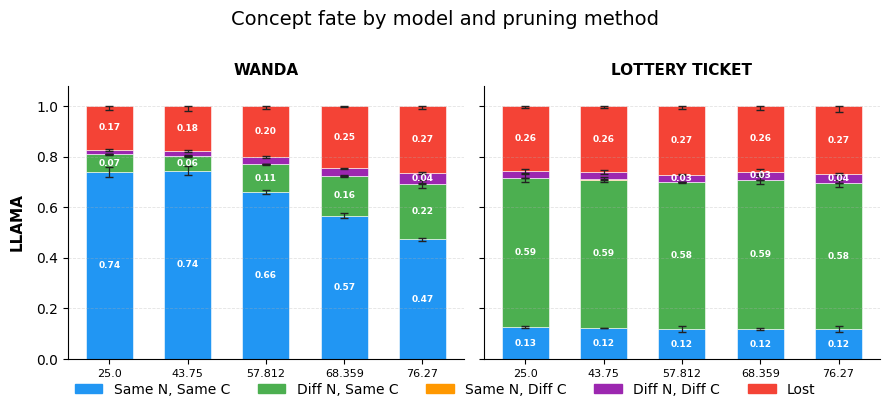

In [48]:
plot_cluster_stability(compiled_model_method_cluster_stability)

In [45]:
import os
import json
import torch

models  = ['BERT', 'BOWMAN', 'LLAMA']
methods = ['CoFi']
def build_reindex_mapping(pruned_neurons, total=1024):
    """
    Maps dense neuron indices to their sparse equivalents.
    Pruned neurons map to None; survivors are re-indexed 0, 1, 2, ...
    
    Example:
        dense:  1 2 3 4 5
        pruned: [2, 3, 4]
        result: {1:0, 2:None, 3:None, 4:None, 5:1}
    """
    pruned_set = set(pruned_neurons)
    mapping = {}
    sparse_idx = 0
    ct=0 #ct how many nones so if muktople neurons pruned out each one is mapped by a none
    for dense_idx in range(total):
        if dense_idx in pruned_set:
            continue
        else:
            mapping[sparse_idx] = dense_idx
            sparse_idx += 1

    return mapping


pruned=[438,640]
reammpa_llama = build_reindex_mapping(pruned)
purned= [3,    6,    8,   39,   45,   64,   91,  105,  107,  110,  125,  128, 132,  135,  142,  160,  180,  186,  188,  190,  201,  203,  212,  219, \
          224,  253,  260,  263,  272,  276,  287,  288,  302,  306,  310,  313, \
          315,  344,  361,  382,  385,  392,  395,  396,  399,  400,  401,  402,\
          403,  404,  408,  409,  410,  412,  414,  415,  416,  419,  420,  424,\
          426,  427,  428,  433,  435,  437,  438,  442,  443,  444,  446,  447,\
          448,  449,  451,  452,  455,  459,  460,  461,  463,  467,  468,  471,\
          472,  473,  474,  476,  477,  478,  482,  487,  488,  489,  490,  491,\
          492,  494,  495,  497,  499,  500,  501,  502,  503,  504,  505,  506,\
          508,  509,  510,  513,  514,  516,  518,  519,  522,  524,  525,  526,\
          527,  529,  536,  539,  543,  548,  549,  551,  553,  555,  556,  557,\
          559,  561,  564,  565,  570,  572,  573,  574,  575,  576,  578,  582,\
          583,  585,  588,  590,  591,  593,  594,  596,  597,  598,  601,  607,\
          608,  610,  611,  612,  613,  614,  615,  616,  617,  618,  620,  621,\
          624,  627,  628,  629,  630,  632,  633,  634,  636,  637,  638,  641,\
          643,  645,  646,  648,  651,  652,  657,  658,  659,  661,  664,  666,\
          667,  670,  671,  677,  681,  686,  701,  702,  715,  716,  718,  719,\
          767,  778,  809,  819,  835,  842,  843,  845,  847,  848,  849,  852,\
          855,  858,  862,  863,  876,  882,  883,  885,  886,  887,  889,  890,\
          891,  892,  893,  894,  895,  899,  901,  902,  903,  908,  910,  911,\
          912,  913,  915,  919,  920,  924,  931,  944,  958,  973,  978,  985,\
          990,  993, 1015, 1016]

# Usage:
# mappings = load_mappings()
# sparse_idx = mappings['BERT']['CoFi']['Run0.25_5'][3][dense_neuron]
reammpa_bowamn = build_reindex_mapping(purned)

In [20]:
reammpa_bowamn[3]

4

In [88]:


all_bowman_cps_common = (r1.union(r2).union(r3)) & (r25_1.union(r25_2).union(r25_3))
clsutersdense = {1: u1, 2: u2, 3: u3}
clsutersparse = {1: u25_1, 2: u25_2, 3: u25_3}
mapp = load_mappings()

dense_map = concept_neuron_map(clsutersdense)
sparse_map = concept_neuron_map(clsutersparse, mapp['BERT']['CoFi']['Run0.25_7'])

same_cluster=0
sn=0
for cp in all_bowman_cps_common:
    if (dense_map[cp].keys()&sparse_map[cp].keys()) :
        for clus in sparse_map[cp].keys():
            if dense_map[cp][clus] & sparse_map[cp][clus]:
                sn += 1
            else:
                same_cluster+=1
sn/len(dense_map)

0.9284294234592445

In [72]:
(0.805168986083499+0.7932405566600398+0.7773359840954275)/3

0.7919151756129889

In [11]:
u25

defaultdict(set,
            {87: {'hyp:tag:ex',
              'hyp:tok:human',
              'hyp:tok:outdoors',
              'hyp:tok:outside'},
             35: {'hyp:tag:ex', 'hyp:tok:standing', 'oth:overlap:overlap75'},
             80: {'hyp:tok:rodeo',
              'hyp:tok:something',
              'hyp:tok:volleyball',
              'oth:overlap:overlap75',
              'pre:tok:sleeping'},
             12: {'hyp:tok:asleep',
              'hyp:tok:eating',
              'hyp:tok:in',
              'hyp:tok:sleeping'},
             192: {'hyp:tok:birthday',
              'hyp:tok:for',
              'hyp:tok:tall',
              'hyp:tok:to'},
             285: {'hyp:tok:grass',
              'hyp:tok:indoors',
              'hyp:tok:inside',
              'hyp:tok:riding',
              'hyp:tok:standing'},
             272: {'hyp:tag:ex',
              'hyp:tok:human',
              'hyp:tok:outdoors',
              'hyp:tok:outside',
              'hyp:tok:water'},
     

In [12]:
u0

defaultdict(set,
            {577: {'hyp:tok:alone',
              'hyp:tok:driving',
              'hyp:tok:running',
              'hyp:tok:swimming',
              'hyp:tok:tv'},
             540: {'hyp:tok:after',
              'hyp:tok:for',
              'hyp:tok:to',
              'hyp:tok:wife'},
             463: {'hyp:tag:prp$',
              'hyp:tag:vb',
              'hyp:tok:after',
              'hyp:tok:for',
              'hyp:tok:party'},
             286: {'hyp:tag:in', 'hyp:tok:eating'},
             848: {'hyp:tag:ex',
              'hyp:tok:human',
              'hyp:tok:near',
              'hyp:tok:person',
              'hyp:tok:something'},
             845: {'hyp:tag:in', 'hyp:tok:driving'}})